In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

df= pd.read_csv(r'c:\Users\ayubi\Downloads\ml-assessment-ayush-kumar\data\q3_retail_promotions.csv',parse_dates=['transaction_date'])

print("Dataset Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)
print("\nFirst 3 rows:")
print(df.head(3))

df['year']         = df['transaction_date'].dt.year
df['month']        = df['transaction_date'].dt.month
df['day_of_week']  = df['transaction_date'].dt.dayofweek
df['is_month_end'] = (df['transaction_date'].dt.day >= 25).astype(int)

print("\nNew date columns added. Sample of resulting dataframe:")
print(df[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head(10).to_string(index=False))
 
print(f"\nDate range: {df['transaction_date'].min().date()}  →  {df['transaction_date'].max().date()}")
print(f"is_month_end distribution:\n{df['is_month_end'].value_counts().to_string()}")

Dataset Shape: (1200, 9)

Column dtypes:
transaction_date       datetime64[us]
store_id                        int64
store_size                        str
location_type                     str
promotion_type                    str
is_weekend                      int64
is_festival                     int64
competition_density             int64
items_sold                      int64
dtype: object

First 3 rows:
  transaction_date  store_id store_size location_type  promotion_type  \
0       2022-01-01        28      small    semi-urban       free_gift   
1       2022-01-01         5     medium    semi-urban       free_gift   
2       2022-01-02        13      small    semi-urban  loyalty_points   

   is_weekend  is_festival  competition_density  items_sold  
0           1            0                    5         224  
1           1            1                    1         348  
2           1            0                    6         249  

New date columns added. Sample of resulting da

In [2]:
df = df.sort_values('transaction_date').reset_index(drop=True)

split_idx = int(len(df) * 0.80)
split_date = df.loc[split_idx, 'transaction_date']
 
train_df = df.iloc[:split_idx].copy()
test_df  = df.iloc[split_idx:].copy()
 
print(f"Total records : {len(df)}")
print(f"Train records : {len(train_df)}  ({len(train_df)/len(df)*100:.1f}%)")
print(f"Test records  : {len(test_df)}   ({len(test_df)/len(df)*100:.1f}%)")
print(f"Train period  : {train_df['transaction_date'].min().date()} → {train_df['transaction_date'].max().date()}")
print(f"Test period   : {test_df['transaction_date'].min().date()}  → {test_df['transaction_date'].max().date()}")
print(f"Split at index: {split_idx}  (first test date: {split_date.date()})")

Total records : 1200
Train records : 960  (80.0%)
Test records  : 240   (20.0%)
Train period  : 2022-01-01 → 2024-06-11
Test period   : 2024-06-12  → 2024-12-31
Split at index: 960  (first test date: 2024-06-12)


# ### Why Random Split is Inappropriate for Time-Ordered Data
# 
# A **random train-test split** on time-series / time-ordered data causes **data leakage**: future observations can leak into the training set, allowing the model to inadvertently learn patterns that it would not have access to in real deployment.
# For example, a random split could train on December 2024 data and test on January 2022 data — the model would have already "seen the future."
#
# A **temporal split** preserves the chronological order: the model is trained exclusively on older records and evaluated on unseen future records, faithfully simulating how the model would perform in production. 
# This gives an honest, unbiased estimate of generalisation performance.

In [3]:
TARGET = 'items_sold'
DROP_COLS = ['transaction_date', 'store_id', TARGET]
 
categorical_features = ['promotion_type', 'location_type', 'store_size']
numerical_features   = [c for c in df.columns
                        if c not in DROP_COLS + categorical_features]
 
print("Categorical features:", categorical_features)
print("Numerical features  :", numerical_features)

X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df[TARGET]
X_test  = test_df.drop(columns=DROP_COLS)
y_test  = test_df[TARGET]

print(f"\nX_train shape: {X_train.shape}  |  X_test shape: {X_test.shape}")

preprocessor = ColumnTransformer(transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features),
        ('num', StandardScaler(), numerical_features),
    ],
    remainder='drop'
)
 
print("\nPreprocessor defined:")
print(preprocessor)

Categorical features: ['promotion_type', 'location_type', 'store_size']
Numerical features  : ['is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']

X_train shape: (960, 10)  |  X_test shape: (240, 10)

Preprocessor defined:
ColumnTransformer(transformers=[('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['promotion_type', 'location_type',
                                  'store_size']),
                                ('num', StandardScaler(),
                                 ['is_weekend', 'is_festival',
                                  'competition_density', 'year', 'month',
                                  'day_of_week', 'is_month_end'])])


✔  Linear Regression pipeline fitted.
✔  Random Forest Regressor pipeline fitted.
  Linear Regression
  RMSE : 27.1252
  MAE  : 21.0715
  Random Forest Regressor
  RMSE : 31.2113
  MAE  : 25.1148

Model Performance Summary:
                            RMSE      MAE
Model                                    
Linear Regression        27.1252  21.0715
Random Forest Regressor  31.2113  25.1148


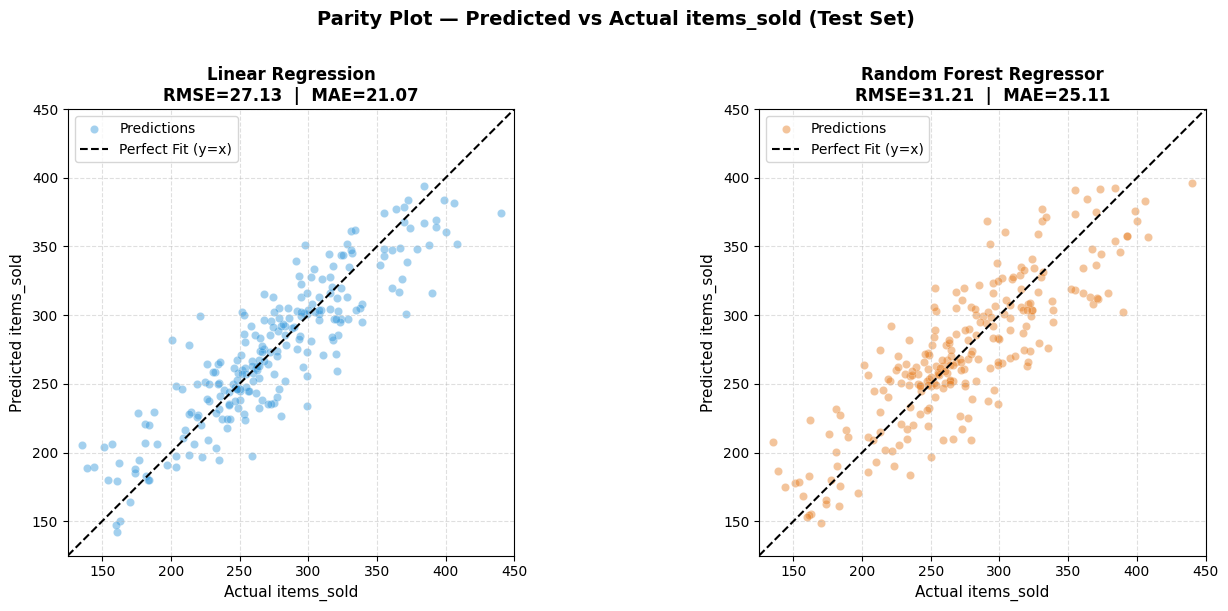


Random Forest — All Feature Importances:
                      Feature  Importance
                  is_festival    0.176311
             store_size_small    0.162564
          location_type_urban    0.112462
                  day_of_week    0.091558
                   is_weekend    0.064125
          competition_density    0.062869
          location_type_rural    0.053278
                        month    0.052139
             store_size_large    0.051411
          promotion_type_bogo    0.032785
            store_size_medium    0.029421
promotion_type_loyalty_points    0.024955
                         year    0.020878
 promotion_type_flat_discount    0.018462
     location_type_semi-urban    0.018028
promotion_type_category_offer    0.012138
     promotion_type_free_gift    0.009429
                 is_month_end    0.007189

Top 5 Most Influential Features:
            Feature  Importance
        is_festival    0.176311
   store_size_small    0.162564
location_type_urban    0.11246

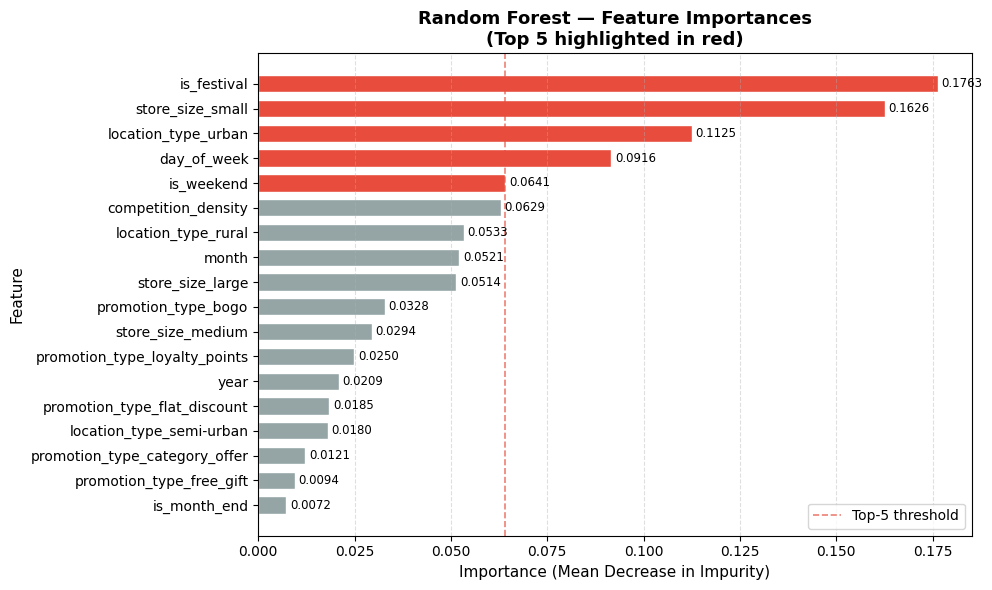

In [5]:
lr_pipeline = Pipeline([('preprocessor', preprocessor),('model', LinearRegression()),])
 
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)),
])

lr_pipeline.fit(X_train, y_train)
print("✔  Linear Regression pipeline fitted.")
 
rf_pipeline.fit(X_train, y_train)
print("✔  Random Forest Regressor pipeline fitted.")

def evaluate_model(name, pipeline, X_test, y_test):
    y_pred = pipeline.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    print(f"  {name}")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    return y_pred, rmse, mae

lr_pred, lr_rmse, lr_mae = evaluate_model("Linear Regression",       lr_pipeline, X_test, y_test)
rf_pred, rf_rmse, rf_mae = evaluate_model("Random Forest Regressor", rf_pipeline, X_test, y_test)

summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest Regressor'],
    'RMSE':  [lr_rmse, rf_rmse],
    'MAE':   [lr_mae,  rf_mae],
}).set_index('Model').round(4)
print("\nModel Performance Summary:")
print(summary.to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
 
for ax, name, y_pred, rmse, mae, color in zip(
    axes,
    ['Linear Regression', 'Random Forest Regressor'],
    [lr_pred, rf_pred],
    [lr_rmse, rf_rmse],
    [lr_mae,  rf_mae],
    ['#3498db', '#e67e22']
):
    mn = min(y_test.min(), y_pred.min()) - 10
    mx = max(y_test.max(), y_pred.max()) + 10
 
    ax.scatter(y_test, y_pred, alpha=0.45, s=35, color=color,
               edgecolors='white', linewidths=0.3, label='Predictions')
    ax.plot([mn, mx], [mn, mx], 'k--', linewidth=1.5, label='Perfect Fit (y=x)')
    ax.set_xlim(mn, mx)
    ax.set_ylim(mn, mx)
    ax.set_title(f'{name}\nRMSE={rmse:.2f}  |  MAE={mae:.2f}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Actual items_sold', fontsize=11)
    ax.set_ylabel('Predicted items_sold', fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_aspect('equal', adjustable='box')
 
plt.suptitle('Parity Plot — Predicted vs Actual items_sold (Test Set)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot1_parity_plots.png', dpi=150, bbox_inches='tight')
plt.show()


cat_feature_names = (lr_pipeline.named_steps['preprocessor']
                     .named_transformers_['cat']
                     .get_feature_names_out(categorical_features))
all_feature_names = list(cat_feature_names) + numerical_features
 
rf_importances = rf_pipeline.named_steps['model'].feature_importances_
 
importances_df = pd.DataFrame({
    'Feature':    all_feature_names,
    'Importance': rf_importances,
}).sort_values('Importance', ascending=False).reset_index(drop=True)
 
print("\nRandom Forest — All Feature Importances:")
print(importances_df.to_string(index=False))
 
print("\nTop 5 Most Influential Features:")
top5 = importances_df.head(5)
print(top5.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 6))
 
palette = ['#e74c3c' if i < 5 else '#95a5a6'
           for i in range(len(importances_df))]
 
bars = ax.barh(importances_df['Feature'][::-1],
               importances_df['Importance'][::-1],
               color=palette[::-1], edgecolor='white', height=0.7)
 
# Highlight top 5
for i, (bar, imp) in enumerate(zip(bars, importances_df['Importance'][::-1])):
    ax.text(imp + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{imp:.4f}', va='center', ha='left', fontsize=8.5)
 
ax.axvline(importances_df['Importance'].iloc[4], color='#e74c3c',
           linestyle='--', linewidth=1.2, alpha=0.7, label='Top-5 threshold')
ax.set_title('Random Forest — Feature Importances\n(Top 5 highlighted in red)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_ylabel('Feature', fontsize=11)
ax.legend(fontsize=10)
ax.grid(True, axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('plot2_feature_importances.png', dpi=150)
plt.show()

# ### Top 5 Most Influential Features 
# 
# The Random Forest feature importances reveal which features most consistently reduce prediction error across all trees:
#
# 1. **is_festival** (0.176) — Festival days are the single strongest driver, producing the largest lift in items sold which are essential for demand planning around events
# 2. **store_size_small** (0.163) — Store format is the second most important signal; smaller stores have a distinct and consistent sales ceiling
# 3. **location_type_urban** (0.112) — Urban stores experience markedly different footfall patterns versus rural/semi-urban, making location a critical input
# 4. **day_of_week** (0.092) — The engineered weekday feature captures the weekly purchase rhythm, a direct payoff from the date feature engineering in Task 1
# 5. **is_weekend** (0.064) — Weekend vs weekday behaviour drives a significant volume differential independent of the raw day_of_week signal
#
# The two engineered temporal features (`day_of_week`, `is_weekend`) both appear in the top 5